## 1. Install & Import Library

In [1]:
!pip install ultralytics albumentations opencv-python-headless -q
!pip install matplotlib seaborn scikit-learn pyyaml -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 21.9 MB/s eta 0:00:00


In [2]:
import os, shutil, random, glob, zipfile, json, yaml, warnings
from pathlib import Path
from collections import defaultdict
import csv
from ultralytics.utils import callbacks as yolo_callbacks
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
import cv2
from PIL import Image
import albumentations as A
from collections import Counter
from sklearn.metrics import (
    confusion_matrix, classification_report,
    precision_score, recall_score, accuracy_score
)
from ultralytics import YOLO

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

CLASS_NAMES  = ['kanan', 'kiri', 'lurus', 'rusak', 'terhalang']
NUM_CLASSES  = len(CLASS_NAMES)
ROBOFLOW_REMAP = {0: 0, 1: 1, 2: 2}
print(f'Kelas yang digunakan: {CLASS_NAMES}')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Kelas yang digunakan: ['kanan', 'kiri', 'lurus', 'rusak', 'terhalang']


## 2. Data Preparation


In [3]:
from google.colab import drive
drive.mount('/content/drive')

ROBOFLOW_ZIP     = '/content/drive/MyDrive/METOPEN/Guiding Block.v1i.yolov8.zip'
LABELSTUDIO_ZIP  = '/content/drive/MyDrive/METOPEN/dataset.zip'
BASE_DIR    = '/content/guiding_block'
EXTRACT_DIR = os.path.join(BASE_DIR, 'raw')
MERGED_DIR  = os.path.join(BASE_DIR, 'merged')
MERGED_IMGS = os.path.join(MERGED_DIR, 'images')
MERGED_LBLS = os.path.join(MERGED_DIR, 'labels')

for d in [EXTRACT_DIR, MERGED_IMGS, MERGED_LBLS]:
    os.makedirs(d, exist_ok=True)
print(f'   Base  : {BASE_DIR}')
print(f'   Merged: {MERGED_DIR}')

Mounted at /content/drive
   Base  : /content/guiding_block
   Merged: /content/guiding_block/merged


In [4]:
RF_EXTRACT = os.path.join(EXTRACT_DIR, 'roboflow')
LS_EXTRACT = os.path.join(EXTRACT_DIR, 'labelstudio')

with zipfile.ZipFile(ROBOFLOW_ZIP, 'r') as z:
    z.extractall(RF_EXTRACT)
print(f'   → {RF_EXTRACT}')

with zipfile.ZipFile(LABELSTUDIO_ZIP, 'r') as z:
    z.extractall(LS_EXTRACT)
print(f'   → {LS_EXTRACT}')

   → /content/guiding_block/raw/roboflow
   → /content/guiding_block/raw/labelstudio


In [5]:
ls_class_count = Counter()

for lbl_file in Path(LS_EXTRACT).rglob("*.txt"):
    with open(lbl_file) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) == 5:
                cls = int(float(parts[0]))
                ls_class_count[cls] += 1

print("Distribusi kelas Label Studio:")
for cls_id in sorted(ls_class_count.keys()):
    print(f"  class {cls_id}: {ls_class_count[cls_id]} bounding box")

Distribusi kelas Label Studio:
  class 0: 46 bounding box
  class 1: 18 bounding box
  class 2: 1198 bounding box
  class 3: 108 bounding box
  class 4: 133 bounding box


In [6]:
rf_class_count = Counter()

for lbl_file in Path(RF_EXTRACT).rglob("*.txt"):
    with open(lbl_file) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) == 5:
                try:
                    cls = int(float(parts[0]))
                    rf_class_count[cls] += 1
                except ValueError:
                    continue

print("Distribusi kelas Roboflow:")
for cls_id in sorted(rf_class_count.keys()):
    print(f"  class {cls_id}: {rf_class_count[cls_id]} bounding box")

Distribusi kelas Roboflow:
  class 0: 791 bounding box
  class 1: 800 bounding box
  class 2: 892 bounding box


In [7]:
def read_yolo_label(lbl_path):
    bboxes, labels = [], []
    if not os.path.exists(lbl_path):
        return bboxes, labels
    if Path(lbl_path).name in ['classes.txt', 'README.roboflow.txt', 'README.dataset.txt']:
        return bboxes, labels
    with open(lbl_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) == 5:
                cls  = int(parts[0])
                bbox = [float(x) for x in parts[1:]]
                bboxes.append(bbox)
                labels.append(cls)
    return bboxes, labels

def write_yolo_label(lbl_path, bboxes, labels):
    with open(lbl_path, 'w') as f:
        for cls, bbox in zip(labels, bboxes):
            f.write(f'{cls} {" ".join([f"{v:.6f}" for v in bbox])}\n')

IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp'}

In [8]:
def merge_roboflow(rf_root, img_dst, lbl_dst, remap=None, prefix='rf'):
    copied = 0
    skipped = 0
    for split in ['train', 'valid', 'test']:
        img_dir = os.path.join(rf_root, split, 'images')
        lbl_dir = os.path.join(rf_root, split, 'labels')
        if not os.path.isdir(img_dir):
            continue
        for img_path in Path(img_dir).iterdir():
            if img_path.suffix.lower() not in IMG_EXTS:
                continue
            lbl_path = Path(lbl_dir) / (img_path.stem + '.txt')
            if not lbl_path.exists():
                skipped += 1
                continue
            bboxes, labels = read_yolo_label(str(lbl_path))
            if not labels:
                skipped += 1
                continue
            if remap:
                labels = [remap.get(l, l) for l in labels]

            new_name = f'{prefix}_{split}_{img_path.stem}'
            dst_img  = os.path.join(img_dst, new_name + img_path.suffix)
            dst_lbl  = os.path.join(lbl_dst, new_name + '.txt')

            shutil.copy(str(img_path), dst_img)
            write_yolo_label(dst_lbl, bboxes, labels)
            copied += 1

    print(f'  Roboflow → {copied} file disalin, {skipped} dilewati')
    return copied


def merge_labelstudio(ls_root, img_dst, lbl_dst, remap=None, prefix='ls'):
    img_dir = Path(ls_root) / 'dataset' / 'images'
    lbl_dir = Path(ls_root) / 'dataset' / 'labels'

    if not img_dir.exists() or not lbl_dir.exists():
        print('Struktur Label Studio tidak ditemukan')
        return 0

    stem_to_lbl = {}
    for lbl_file in lbl_dir.iterdir():
        if lbl_file.suffix != '.txt':
            continue
        name = lbl_file.stem
        if '__' in name:
            name = name.split('__', 1)[1]
        name = name.replace('%5C', '_').replace('\\', '_')
        if 'dataset_' in name:
            name = name.split('dataset_', 1)[1]
        stem_to_lbl[name] = lbl_file

    copied, skipped = 0, 0
    for img_path in img_dir.iterdir():
        if img_path.suffix.lower() not in IMG_EXTS:
            continue

        lbl_file = stem_to_lbl.get(img_path.stem)
        if lbl_file is None:
            skipped += 1
            continue

        bboxes, labels = read_yolo_label(str(lbl_file))
        if not labels:
            skipped += 1
            continue

        if remap:
            labels = [remap.get(l, l) for l in labels]

        new_name = f'{prefix}_{img_path.stem}'
        shutil.copy(str(img_path), os.path.join(img_dst, new_name + img_path.suffix))
        write_yolo_label(os.path.join(lbl_dst, new_name + '.txt'), bboxes, labels)
        copied += 1

    print(f'  Label Studio → {copied} file disalin, {skipped} dilewati')
    return copied

n_rf = merge_roboflow(RF_EXTRACT, MERGED_IMGS, MERGED_LBLS,
                      remap=ROBOFLOW_REMAP, prefix='rf')
n_ls = merge_labelstudio(LS_EXTRACT, MERGED_IMGS, MERGED_LBLS, prefix='ls')

total = len(list(Path(MERGED_IMGS).iterdir()))
print(f'\nTotal gambar setelah merge: {total}')
print(f'   Roboflow    : {n_rf}')
print(f'   Label Studio: {n_ls}')

  Roboflow → 2392 file disalin, 0 dilewati
  Label Studio → 1495 file disalin, 0 dilewati

Total gambar setelah merge: 3887
   Roboflow    : 2392
   Label Studio: 1495


Distribusi kelas: 
  kanan          :   837  ████████████████
  kiri           :   818  ████████████████
  lurus          :  2090  █████████████████████████████████████████
  rusak          :   108  ██
  terhalang      :   133  ██


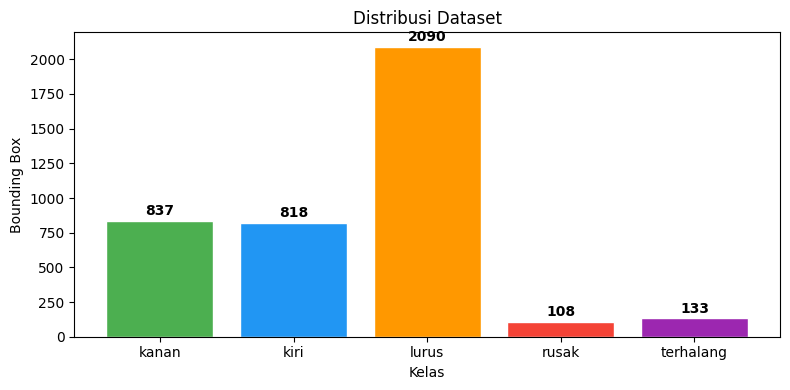

In [9]:
def count_classes(label_dir, class_names):
    counts = defaultdict(int)
    for lbl_file in Path(label_dir).glob('*.txt'):
        bboxes, labels = read_yolo_label(str(lbl_file))
        for l in labels:
            if l < len(class_names):
                counts[class_names[l]] += 1
    return {c: counts[c] for c in class_names}

class_counts = count_classes(MERGED_LBLS, CLASS_NAMES)
print('Distribusi kelas: ')
for cls, cnt in class_counts.items():
    bar = '█' * (cnt // 50)
    print(f'  {cls:15s}: {cnt:5d}  {bar}')

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#4CAF50', '#2196F3', '#FF9800', '#F44336', '#9C27B0']
bars = ax.bar(class_counts.keys(), class_counts.values(), color=colors, edgecolor='white')
for bar, val in zip(bars, class_counts.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            str(val), ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_title('Distribusi Dataset', fontsize=12)
ax.set_ylabel('Bounding Box')
ax.set_xlabel('Kelas')
plt.tight_layout()
plt.show()

## 3. Data Preprocessing

In [10]:
PREPROC_DIR  = os.path.join(BASE_DIR, 'preprocessed')
PREPROC_IMGS = os.path.join(PREPROC_DIR, 'images')
PREPROC_LBLS = os.path.join(PREPROC_DIR, 'labels')
os.makedirs(PREPROC_IMGS, exist_ok=True)
os.makedirs(PREPROC_LBLS, exist_ok=True)

IMG_SIZE = 640

def letterbox_resize(img, target_size=640, pad_color=(114, 114, 114)):
    h, w = img.shape[:2]
    scale = target_size / max(h, w)
    new_w, new_h = int(w * scale), int(h * scale)
    img_resized = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_LINEAR)

    canvas = np.full((target_size, target_size, 3), pad_color, dtype=np.uint8)
    pad_top  = (target_size - new_h) // 2
    pad_left = (target_size - new_w) // 2
    canvas[pad_top:pad_top+new_h, pad_left:pad_left+new_w] = img_resized

    return canvas, scale, (pad_left, pad_top)


def adjust_yolo_label_letterbox(bboxes, labels, orig_h, orig_w,
                                 target_size=640, pad_left=0, pad_top=0, scale=1.0):
    adjusted_bboxes = []
    valid_labels = []
    for bbox, cls in zip(bboxes, labels):
        cx, cy, bw, bh = bbox

        cx_px = cx * orig_w
        cy_px = cy * orig_h
        bw_px = bw * orig_w
        bh_px = bh * orig_h

        cx_new = (cx_px * scale + pad_left) / target_size
        cy_new = (cy_px * scale + pad_top)  / target_size
        bw_new = (bw_px * scale) / target_size
        bh_new = (bh_px * scale) / target_size

        cx_new = max(0.001, min(0.999, cx_new))
        cy_new = max(0.001, min(0.999, cy_new))
        bw_new = max(0.001, min(0.999, bw_new))
        bh_new = max(0.001, min(0.999, bh_new))

        if bw_new < 0.005 or bh_new < 0.005:
            continue

        adjusted_bboxes.append([cx_new, cy_new, bw_new, bh_new])
        valid_labels.append(cls)

    return adjusted_bboxes, valid_labels


def preprocess_dataset(img_src_dir, lbl_src_dir, img_dst_dir, lbl_dst_dir,
                        target_size=640):
    all_imgs = list(Path(img_src_dir).iterdir())
    success, skipped_corrupt, skipped_nolabel = 0, 0, 0

    for img_path in all_imgs:
        if img_path.suffix.lower() not in IMG_EXTS:
            continue

        img = cv2.imread(str(img_path))
        if img is None:
            skipped_corrupt += 1
            continue

        orig_h, orig_w = img.shape[:2]
        lbl_path = Path(lbl_src_dir) / (img_path.stem + '.txt')
        bboxes, labels = read_yolo_label(str(lbl_path))

        if not labels:
            skipped_nolabel += 1
            continue

        img_lb, scale, (pad_left, pad_top) = letterbox_resize(img, target_size)

        adj_bboxes, adj_labels = adjust_yolo_label_letterbox(
            bboxes, labels, orig_h, orig_w, target_size, pad_left, pad_top, scale
        )
        if not adj_labels:
            skipped_nolabel += 1
            continue

        cv2.imwrite(str(Path(img_dst_dir) / img_path.name), img_lb)
        write_yolo_label(str(Path(lbl_dst_dir) / (img_path.stem + '.txt')),
                         adj_bboxes, adj_labels)
        success += 1

    print(f'{success}')
    print(f'   Skip: {skipped_corrupt}')
    print(f'   Dilewati (no bbox): {skipped_nolabel}')
    return success

n_preproc = preprocess_dataset(MERGED_IMGS, MERGED_LBLS,
                                PREPROC_IMGS, PREPROC_LBLS, IMG_SIZE)

3887
   Skip: 0
   Dilewati (no bbox): 0


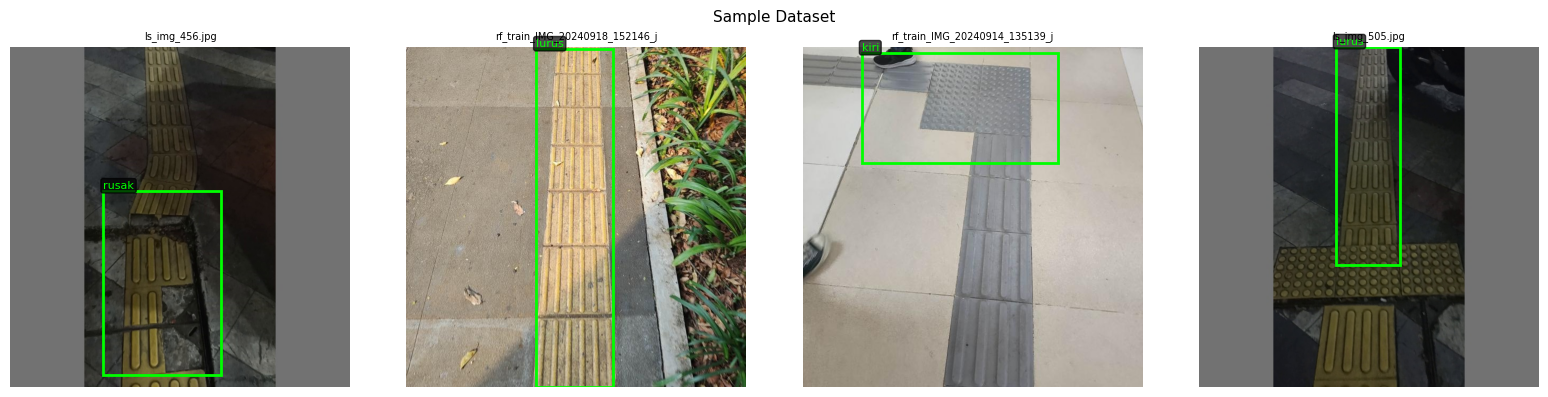

In [11]:
sample_imgs = random.sample(list(Path(PREPROC_IMGS).iterdir()), min(4, n_preproc))

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, img_path in zip(axes, sample_imgs):
    img = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img_rgb.shape[:2]

    lbl_path = Path(PREPROC_LBLS) / (img_path.stem + '.txt')
    bboxes, labels = read_yolo_label(str(lbl_path))

    ax.imshow(img_rgb)
    for bbox, cls in zip(bboxes, labels):
        cx, cy, bw, bh = bbox
        x1 = (cx - bw/2) * w
        y1 = (cy - bh/2) * h
        rect = patches.Rectangle((x1, y1), bw*w, bh*h,
                                   linewidth=2, edgecolor='lime', facecolor='none')
        ax.add_patch(rect)
        ax.text(x1, y1-5, CLASS_NAMES[cls], color='lime', fontsize=8,
                bbox=dict(boxstyle='round,pad=0.2', fc='black', alpha=0.7))
    ax.set_title(img_path.name[:30], fontsize=7)
    ax.axis('off')

plt.suptitle('Sample Dataset', fontsize=11)
plt.tight_layout()
plt.show()

## 4. Data Augmentation


In [12]:
AUG_DIR  = os.path.join(BASE_DIR, 'augmented')
AUG_IMGS = os.path.join(AUG_DIR, 'images')
AUG_LBLS = os.path.join(AUG_DIR, 'labels')
os.makedirs(AUG_IMGS, exist_ok=True)
os.makedirs(AUG_LBLS, exist_ok=True)

for f in Path(PREPROC_IMGS).iterdir():
    shutil.copy(str(f), AUG_IMGS)
for f in Path(PREPROC_LBLS).iterdir():
    shutil.copy(str(f), AUG_LBLS)

print(f'Base dataset tersalin: {len(os.listdir(AUG_IMGS))} gambar')

Base dataset tersalin: 3887 gambar


In [13]:
# ── Bersihkan & buat folder augmented ──
if os.path.exists(AUG_DIR):
    shutil.rmtree(AUG_DIR)
os.makedirs(AUG_IMGS, exist_ok=True)
os.makedirs(AUG_LBLS, exist_ok=True)

TARGET_PER_CLASS = 800

def find_img(stem, img_dir):
    for ext in ['.jpg', '.jpeg', '.png', '.bmp']:
        p = Path(img_dir) / (stem + ext)
        if p.exists():
            return p
    return None

# ── Definisi fungsi & pipeline ──
def get_stems_by_class(img_dir, lbl_dir, class_names):
    class_stems = defaultdict(list)
    for lbl_file in Path(lbl_dir).glob("*.txt"):
        _, labels = read_yolo_label(str(lbl_file))
        for l in set(labels):
            if l < len(class_names):
                class_stems[l].append(lbl_file.stem)
    return class_stems

augment_pipeline = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=0.7),
    A.HueSaturationValue(hue_shift_limit=15, sat_shift_limit=25, val_shift_limit=20, p=0.5),
    A.GaussNoise(var_limit=(10, 50), p=0.4),
    A.MotionBlur(blur_limit=5, p=0.3),
    A.RandomShadow(p=0.3),
    A.Rotate(limit=15, border_mode=cv2.BORDER_REFLECT_101, p=0.5),
    A.Perspective(scale=(0.02, 0.08), p=0.3),
    A.CLAHE(clip_limit=2.0, p=0.3),
], bbox_params=A.BboxParams(
    format="yolo",
    label_fields=["class_labels"],
    min_visibility=0.3,
))

# ── Hitung stems per kelas ──
class_stems = get_stems_by_class(PREPROC_IMGS, PREPROC_LBLS, CLASS_NAMES)

print('Jumlah gambar per kelas sebelum augmentasi:')
for i, cls in enumerate(CLASS_NAMES):
    print(f'  {cls:15s}: {len(class_stems[i])}')

# ── Salin semua data preprocessed ke augmented ──
for f in Path(PREPROC_IMGS).iterdir():
    shutil.copy(str(f), AUG_IMGS)
for f in Path(PREPROC_LBLS).iterdir():
    shutil.copy(str(f), AUG_LBLS)

total_aug = 0

for cls_id, stems in class_stems.items():
    current  = len(stems)
    cls_name = CLASS_NAMES[cls_id]

    if current > TARGET_PER_CLASS:
        remove_stems = random.sample(stems, current - TARGET_PER_CLASS)
        for stem in remove_stems:
            img_path = find_img(stem, AUG_IMGS)
            lbl_path = Path(AUG_LBLS) / (stem + '.txt')
            if img_path and img_path.exists():
                img_path.unlink()
            if lbl_path.exists():
                lbl_path.unlink()
        print(f'  {cls_name:15s}: undersample {current} → {TARGET_PER_CLASS} (hapus {current - TARGET_PER_CLASS} gambar)')

    elif current < TARGET_PER_CLASS:
        needed = TARGET_PER_CLASS - current
        print(f'  {cls_name:15s}: perlu {needed} gambar lagi ({current} → {TARGET_PER_CLASS})')

        pool = stems * (needed // len(stems) + 1)
        random.shuffle(pool)
        pool = pool[:needed]

        gen = 0
        for stem in pool:
            img_src  = find_img(stem, PREPROC_IMGS)
            if img_src is None:
                continue
            lbl_path = Path(PREPROC_LBLS) / (stem + '.txt')
            img      = cv2.imread(str(img_src))
            if img is None:
                continue
            img_rgb        = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            bboxes, labels = read_yolo_label(str(lbl_path))
            if not bboxes:
                continue
            bboxes = [[max(0.001, min(0.999, v)) for v in bb] for bb in bboxes]

            try:
                result = augment_pipeline(image=img_rgb, bboxes=bboxes, class_labels=labels)
                if not result['bboxes']:
                    continue
                new_img  = cv2.cvtColor(result['image'], cv2.COLOR_RGB2BGR)
                new_name = f'aug_{cls_id}_{gen}_{stem}'
                cv2.imwrite(str(Path(AUG_IMGS) / (new_name + img_src.suffix)), new_img)
                write_yolo_label(
                    str(Path(AUG_LBLS) / (new_name + '.txt')),
                    result['bboxes'],
                    [int(float(c)) for c in result['class_labels']]
                )
                gen += 1
            except Exception:
                pass

        total_aug += gen
        print(f'    → {gen}')

    else:
        print(f'  {cls_name:15s}: sudah tepat {TARGET_PER_CLASS}, skip')

print(f'\nTotal gambar baru: {total_aug}')
print(f'Total dataset (target ~{TARGET_PER_CLASS * len(CLASS_NAMES)}): {len(os.listdir(AUG_IMGS))}')

Jumlah gambar per kelas sebelum augmentasi:
  kanan          : 837
  kiri           : 818
  lurus          : 1999
  rusak          : 108
  terhalang      : 133
  lurus          : undersample 1999 → 800 (hapus 1199 gambar)
  kanan          : undersample 837 → 800 (hapus 37 gambar)
  kiri           : undersample 818 → 800 (hapus 18 gambar)
  rusak          : perlu 692 gambar lagi (108 → 800)
    → 621
  terhalang      : perlu 667 gambar lagi (133 → 800)
    → 643

Total gambar baru: 1264
Total dataset (target ~4000): 3898


Distribusi kelas setelah augmentasi:
  kanan          : 799
  kiri           : 799
  lurus          : 799
  rusak          : 729
  terhalang      : 776


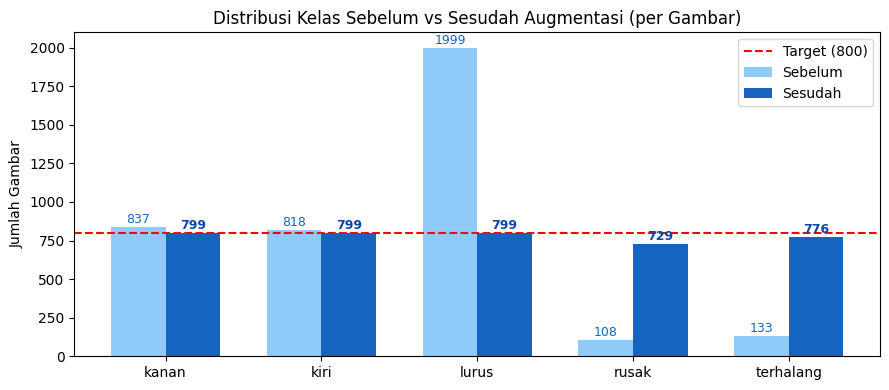

In [14]:
aug_stems_by_class = get_stems_by_class(AUG_IMGS, AUG_LBLS, CLASS_NAMES)
aug_counts_after = {cls: len(aug_stems_by_class[i]) for i, cls in enumerate(CLASS_NAMES)}
class_counts_img = {cls: len(class_stems[i]) for i, cls in enumerate(CLASS_NAMES)}

print('Distribusi kelas setelah augmentasi:')
for cls, cnt in aug_counts_after.items():
    print(f'  {cls:15s}: {cnt}')

x = np.arange(len(CLASS_NAMES))
w = 0.35
fig, ax = plt.subplots(figsize=(9, 4))
b1 = ax.bar(x - w/2, class_counts_img.values(), w, label='Sebelum', color='#90CAF9')
b2 = ax.bar(x + w/2, aug_counts_after.values(), w, label='Sesudah', color='#1565C0')

for bar, val in zip(b1, class_counts_img.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(val), ha='center', va='bottom', fontsize=9, color='#1565C0')
for bar, val in zip(b2, aug_counts_after.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(val), ha='center', va='bottom', fontsize=9, color='#0D47A1', fontweight='bold')

ax.axhline(y=800, color='red', linestyle='--', linewidth=1.5, label='Target (800)')
ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES)
ax.set_title('Distribusi Kelas Sebelum vs Sesudah Augmentasi (per Gambar)', fontsize=12)
ax.set_ylabel('Jumlah Gambar')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Data Splitting

In [15]:
SPLIT_DIR = os.path.join(BASE_DIR, 'dataset')
for split in ['train', 'valid', 'test']:
    os.makedirs(os.path.join(SPLIT_DIR, split, 'images'), exist_ok=True)
    os.makedirs(os.path.join(SPLIT_DIR, split, 'labels'), exist_ok=True)

valid_stems = []
for img_path in Path(AUG_IMGS).iterdir():
    if img_path.suffix.lower() not in IMG_EXTS:
        continue
    lbl_path = Path(AUG_LBLS) / (img_path.stem + '.txt')
    if lbl_path.exists():
        valid_stems.append(img_path.stem)

random.shuffle(valid_stems)
n = len(valid_stems)
n_train = int(0.80 * n)
n_valid = int(0.10 * n)

splits = {
    'train': valid_stems[:n_train],
    'valid': valid_stems[n_train : n_train + n_valid],
    'test' : valid_stems[n_train + n_valid:]
}


for split_name, stem_list in splits.items():
    for stem in stem_list:
        img_src = find_img(stem, AUG_IMGS)
        lbl_src = Path(AUG_LBLS) / (stem + '.txt')
        if img_src:
            shutil.copy(str(img_src), os.path.join(SPLIT_DIR, split_name, 'images', img_src.name))
            shutil.copy(str(lbl_src), os.path.join(SPLIT_DIR, split_name, 'labels', stem + '.txt'))

print('Hasil splitting:')
for split_name, stem_list in splits.items():
    pct = len(stem_list) / n * 100
    print(f'   {split_name:5s}: {len(stem_list):5d} gambar ({pct:.1f}%)')
print(f'   Total : {n}')

Hasil splitting:
   train:  3118 gambar (80.0%)
   valid:   389 gambar (10.0%)
   test :   391 gambar (10.0%)
   Total : 3898


In [16]:
data_yaml = {
    'path' : SPLIT_DIR,
    'train': 'train/images',
    'val'  : 'valid/images',
    'test' : 'test/images',
    'nc'   : NUM_CLASSES,
    'names': CLASS_NAMES
}

YAML_PATH = os.path.join(BASE_DIR, 'data.yaml')
with open(YAML_PATH, 'w') as f:
    yaml.dump(data_yaml, f, default_flow_style=False, allow_unicode=True)

print(f'data.yaml:')
print(open(YAML_PATH).read())

data.yaml:
names:
- kanan
- kiri
- lurus
- rusak
- terhalang
nc: 5
path: /content/guiding_block/dataset
test: test/images
train: train/images
val: valid/images



## 6. Callbacks


In [17]:
import csv
from ultralytics.utils import callbacks as yolo_callbacks
training_log = []

def on_train_epoch_end(trainer):
    epoch   = trainer.epoch + 1
    metrics = trainer.metrics
    lr      = trainer.optimizer.param_groups[0]['lr']
    loss    = float(trainer.loss.detach().cpu()) if hasattr(trainer.loss, 'detach') else 0.0

    log_entry = {
        'epoch'    : epoch,
        'lr'       : round(lr, 8),
        'train_loss': round(loss, 5),
        'mAP50'    : round(metrics.get('metrics/mAP50(B)', 0), 4),
        'precision': round(metrics.get('metrics/precision(B)', 0), 4),
        'recall'   : round(metrics.get('metrics/recall(B)', 0), 4),
    }
    training_log.append(log_entry)

    if epoch % 10 == 0 or epoch == 1:
        print(f'  [Epoch {epoch:3d}] LR={lr:.2e} | '
              f'Loss={loss:.4f} | '
              f'mAP50={log_entry["mAP50"]:.4f} | '
              f'P={log_entry["precision"]:.4f} | '
              f'R={log_entry["recall"]:.4f}')


def on_train_end(trainer):
    """Callback: simpan log ke CSV saat training selesai."""
    log_path = os.path.join(BASE_DIR, 'training_log.csv')
    if training_log:
        with open(log_path, 'w', newline='') as f:
            writer = csv.DictWriter(f, fieldnames=training_log[0].keys())
            writer.writeheader()
            writer.writerows(training_log)
        print(f'\Training log tersimpan di: {log_path}')

## 7. Modelling – YOLOv8s Training

In [18]:
model = YOLO('yolov8s.pt')
model.add_callback('on_train_epoch_end', on_train_epoch_end)
model.add_callback('on_train_end',       on_train_end)
model.info()

YOLOv8s summary: 129 layers, 11,166,560 parameters, 0 gradients, 28.8 GFLOPs


(129, 11166560, 0, 28.816844800000002)

In [19]:
EPOCHS   = 100
BATCH    = 16
IMG_SZ   = 640
PROJECT  = os.path.join(BASE_DIR, 'runs')
EXP_NAME = 'guiding_block_yolov8s'

print(f'   Epochs   : {EPOCHS} (EarlyStopping patience=20)')
print(f'   Batch    : {BATCH}')
print(f'   LR awal  : 0.001 → final ~0.00001 (cosine annealing)')
print(f'   Optimizer: AdamW + weight_decay=0.0005')
print(f'   Warmup   : 5 epochs\n')

results = model.train(
    data          = YAML_PATH,
    epochs        = EPOCHS,
    imgsz         = IMG_SZ,
    batch         = BATCH,
    patience      = 20,           # EarlyStopping
    optimizer     = 'AdamW',
    lr0           = 0.001,        # LR awal
    lrf           = 0.01,         # LR final = lr0 × lrf
    momentum      = 0.937,
    weight_decay  = 0.0005,
    warmup_epochs = 5,
    warmup_momentum = 0.8,
    warmup_bias_lr  = 0.1,

    project       = PROJECT,
    name          = EXP_NAME,
    device        = 0,            # GPU (ganti 'cpu' jika tidak ada GPU)
    workers       = 4,
    verbose       = True,
    seed          = SEED,
    plots         = True,
    save          = True,
    save_period   = 10,           # simpan checkpoint tiap 10 epoch
    val           = True,
)

BEST_MODEL_PATH = os.path.join(PROJECT, EXP_NAME, 'weights', 'best.pt')
print(f'\n Training selesai!')
print(f'   Best model : {BEST_MODEL_PATH}')

   Epochs   : 100 (EarlyStopping patience=20)
   Batch    : 16
   LR awal  : 0.001 → final ~0.00001 (cosine annealing)
   Optimizer: AdamW + weight_decay=0.0005
   Warmup   : 5 epochs

Ultralytics 8.4.63 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/guiding_block/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=

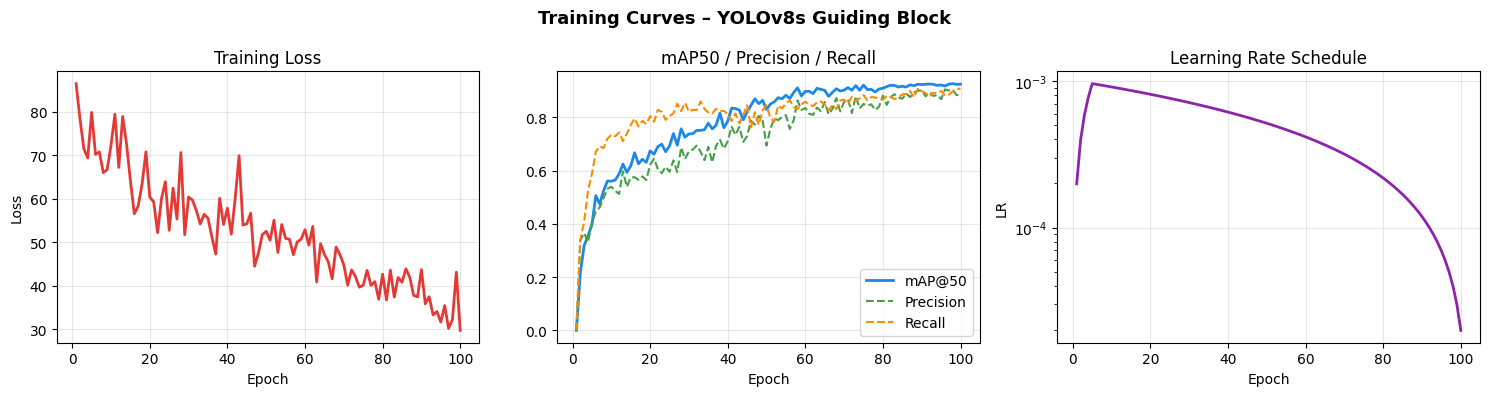

Training curves tersimpan.


In [20]:
if training_log:
    df_log = pd.DataFrame(training_log)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].plot(df_log['epoch'], df_log['train_loss'], color='#E53935', linewidth=2)
    axes[0].set_title('Training Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(df_log['epoch'], df_log['mAP50'], color='#1E88E5', linewidth=2, label='mAP@50')
    axes[1].plot(df_log['epoch'], df_log['precision'], color='#43A047', linewidth=1.5, linestyle='--', label='Precision')
    axes[1].plot(df_log['epoch'], df_log['recall'], color='#FB8C00', linewidth=1.5, linestyle='--', label='Recall')
    axes[1].set_title('mAP50 / Precision / Recall')
    axes[1].set_xlabel('Epoch')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    axes[2].plot(df_log['epoch'], df_log['lr'], color='#8E24AA', linewidth=2)
    axes[2].set_title('Learning Rate Schedule')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('LR')
    axes[2].set_yscale('log')
    axes[2].grid(True, alpha=0.3)

    plt.suptitle('Training Curves – YOLOv8s Guiding Block', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(BASE_DIR, 'training_curves.png'), dpi=150)
    plt.show()
    print('Training curves tersimpan.')
else:
    # Fallback: baca dari results.csv YOLOv8
    results_csv = os.path.join(PROJECT, EXP_NAME, 'results.csv')
    if os.path.exists(results_csv):
        df = pd.read_csv(results_csv)
        df.columns = df.columns.str.strip()
        print('Kolom tersedia:', df.columns.tolist())
        df.plot(x='epoch', y=['metrics/mAP50(B)', 'metrics/precision(B)', 'metrics/recall(B)'],
                figsize=(10, 4), title='Training Metrics')
        plt.tight_layout()
        plt.show()

## 8. Evaluasi

In [21]:
best_model = YOLO(BEST_MODEL_PATH)
print(f'Best model dari: {BEST_MODEL_PATH}')

Best model dari: /content/guiding_block/runs/guiding_block_yolov8s/weights/best.pt


In [22]:
TEST_IMG_DIR = os.path.join(SPLIT_DIR, 'test', 'images')
TEST_LBL_DIR = os.path.join(SPLIT_DIR, 'test', 'labels')

test_results = best_model.val(
    data    = YAML_PATH,
    split   = 'test',
    imgsz   = IMG_SZ,
    batch   = BATCH,
    conf    = 0.25,
    iou     = 0.5,
    device  = 0,
    verbose = True,
    plots   = True
)

print('\n' + '='*50)
print('   METRIK EVALUASI (YOLOv8 val pada test set)')
print('='*50)
print(f'  mAP@50       : {test_results.box.map50:.4f}')
print(f'  mAP@50-95    : {test_results.box.map:.4f}')
print(f'  Precision    : {test_results.box.mp:.4f}')
print(f'  Recall       : {test_results.box.mr:.4f}')
print('='*50)

Ultralytics 8.4.63 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,127,519 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 33.6±21.3 MB/s, size: 113.8 KB)
val: Scanning /content/guiding_block/dataset/test/labels... 391 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 391/391 436.7it/s 0.9s
val: New cache created: /content/guiding_block/dataset/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 25/25 2.9it/s 8.6s
                   all        391        395      0.866      0.872      0.866      0.544
                 kanan         73         73      0.812      0.886      0.861      0.573
                  kiri         78         78       0.85      0.873      0.885      0.548
                 lurus         88         90      0.851      0.756      0.775      0.343
                 rusak         73         73      0.901   

In [23]:
ap50_per_class = test_results.box.ap50
p_per_class    = test_results.box.p
r_per_class    = test_results.box.r

print(f'{"Kelas":15s} | {"Precision":>10s} | {"Recall":>8s} | {"mAP50":>8s}')
print('-' * 52)
for i, cls in enumerate(CLASS_NAMES):
    p = p_per_class[i]    if i < len(p_per_class)    else 0
    r = r_per_class[i]    if i < len(r_per_class)    else 0
    a = ap50_per_class[i] if i < len(ap50_per_class) else 0
    print(f'{cls:15s} | {p:>10.4f} | {r:>8.4f} | {a:>8.4f}')
print('-' * 52)
print(f'{"RATA-RATA":15s} | {test_results.box.mp:>10.4f} | {test_results.box.mr:>8.4f} | {test_results.box.map50:>8.4f}')

Kelas           |  Precision |   Recall |    mAP50
----------------------------------------------------
kanan           |     0.8117 |   0.8857 |   0.8614
kiri            |     0.8502 |   0.8735 |   0.8852
lurus           |     0.8506 |   0.7556 |   0.7746
rusak           |     0.9013 |   0.9178 |   0.8924
terhalang       |     0.9146 |   0.9259 |   0.9181
----------------------------------------------------
RATA-RATA       |     0.8657 |   0.8717 |   0.8664


In [24]:
y_true_all = []
y_pred_all = []

test_imgs = list(Path(TEST_IMG_DIR).iterdir())
print(f'Memproses {len(test_imgs)} gambar test...')

for img_path in test_imgs:
    if img_path.suffix.lower() not in IMG_EXTS:
        continue

    lbl_path = Path(TEST_LBL_DIR) / (img_path.stem + '.txt')
    gt_labels = []
    if lbl_path.exists():
        _, gt_labels = read_yolo_label(str(lbl_path))

    if not gt_labels:
        continue

    # ── Prediksi ──
    preds = best_model.predict(str(img_path), conf=0.25, iou=0.5, verbose=False)
    pred_labels = []
    if preds and preds[0].boxes is not None and len(preds[0].boxes) > 0:
        pred_labels = preds[0].boxes.cls.cpu().numpy().astype(int).tolist()

    if not pred_labels:
        continue

    n = min(len(gt_labels), len(pred_labels))
    y_true_all.extend(gt_labels[:n])
    y_pred_all.extend(pred_labels[:n])

print(f'\n Total pasangan prediksi: {len(y_true_all)}')

Memproses 391 gambar test...

 Total pasangan prediksi: 387


In [25]:
if len(y_true_all) == 0:
    print('Tidak ada prediksi untuk dievaluasi.')
else:
    acc = accuracy_score(y_true_all, y_pred_all)
    prec_macro = precision_score(y_true_all, y_pred_all,
                                  average='macro', zero_division=0)
    rec_macro  = recall_score(y_true_all, y_pred_all,
                               average='macro', zero_division=0)
    prec_weighted = precision_score(y_true_all, y_pred_all,
                                     average='weighted', zero_division=0)
    rec_weighted  = recall_score(y_true_all, y_pred_all,
                                  average='weighted', zero_division=0)

    print('='*50)
    print('   EVALUASI KLASIFIKASI (sklearn)')
    print('='*50)
    print(f'  Accuracy              : {acc:.4f}  ({acc*100:.2f}%)')
    print(f'  Precision (macro)     : {prec_macro:.4f}')
    print(f'  Recall    (macro)     : {rec_macro:.4f}')
    print(f'  Precision (weighted)  : {prec_weighted:.4f}')
    print(f'  Recall    (weighted)  : {rec_weighted:.4f}')
    print('='*50)

    from sklearn.metrics import f1_score
    f1 = f1_score(y_true_all, y_pred_all, average='macro', zero_division=0)
    print(f'  F1-Score  (macro)     : {f1:.4f}')

   EVALUASI KLASIFIKASI (sklearn)
  Accuracy              : 0.9173  (91.73%)
  Precision (macro)     : 0.9170
  Recall    (macro)     : 0.9180
  Precision (weighted)  : 0.9196
  Recall    (weighted)  : 0.9173
  F1-Score  (macro)     : 0.9168


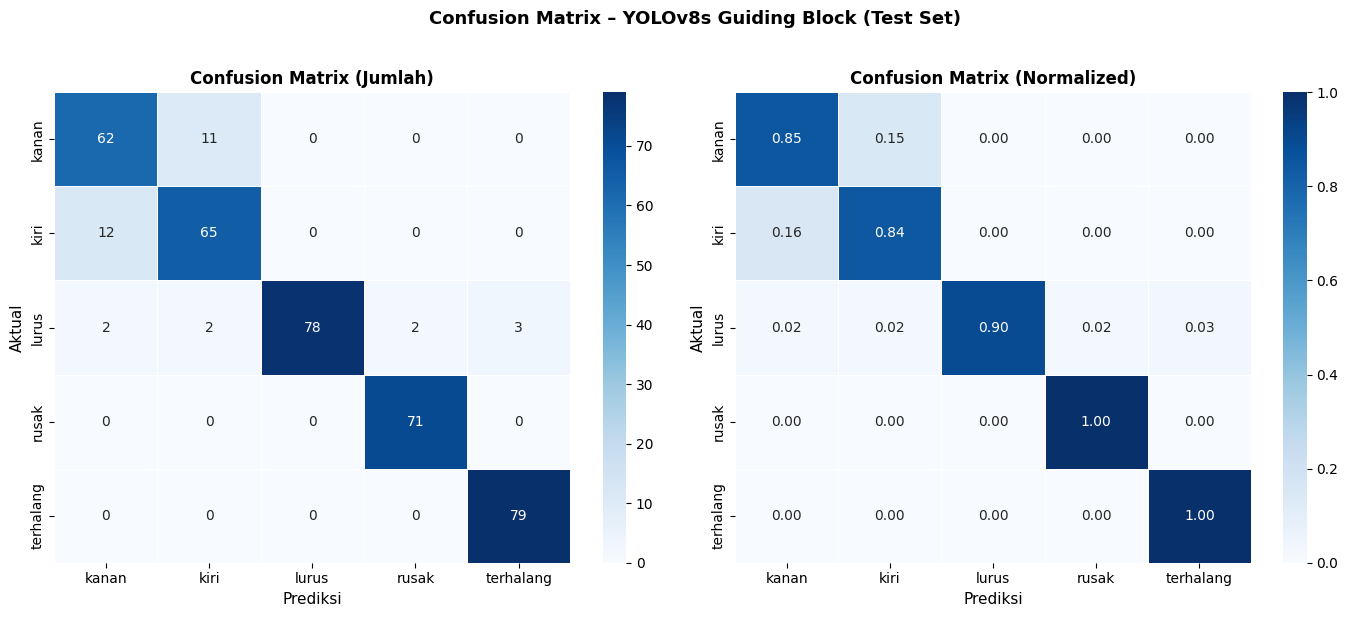

In [26]:
# ─── Confusion Matrix ───
if len(y_true_all) > 0:
    cm      = confusion_matrix(y_true_all, y_pred_all, labels=list(range(NUM_CLASSES)))
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    cm_norm = np.nan_to_num(cm_norm)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Count
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                ax=axes[0], linewidths=0.5)
    axes[0].set_title('Confusion Matrix (Jumlah)', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Prediksi', fontsize=11)
    axes[0].set_ylabel('Aktual', fontsize=11)

    # Normalized
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                ax=axes[1], linewidths=0.5,
                vmin=0, vmax=1)
    axes[1].set_title('Confusion Matrix (Normalized)', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Prediksi', fontsize=11)
    axes[1].set_ylabel('Aktual', fontsize=11)

    plt.suptitle('Confusion Matrix – YOLOv8s Guiding Block (Test Set)',
                 fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(os.path.join(BASE_DIR, 'confusion_matrix.png'),
                dpi=150, bbox_inches='tight')
    plt.show()

In [27]:
# ─── Classification Report lengkap ───
if len(y_true_all) > 0:
    report = classification_report(y_true_all, y_pred_all,
                                   target_names=CLASS_NAMES,
                                   zero_division=0)
    print('='*60)
    print('   CLASSIFICATION REPORT PER KELAS')
    print('='*60)
    print(report)

   CLASSIFICATION REPORT PER KELAS
              precision    recall  f1-score   support

       kanan       0.82      0.85      0.83        73
        kiri       0.83      0.84      0.84        77
       lurus       1.00      0.90      0.95        87
       rusak       0.97      1.00      0.99        71
   terhalang       0.96      1.00      0.98        79

    accuracy                           0.92       387
   macro avg       0.92      0.92      0.92       387
weighted avg       0.92      0.92      0.92       387



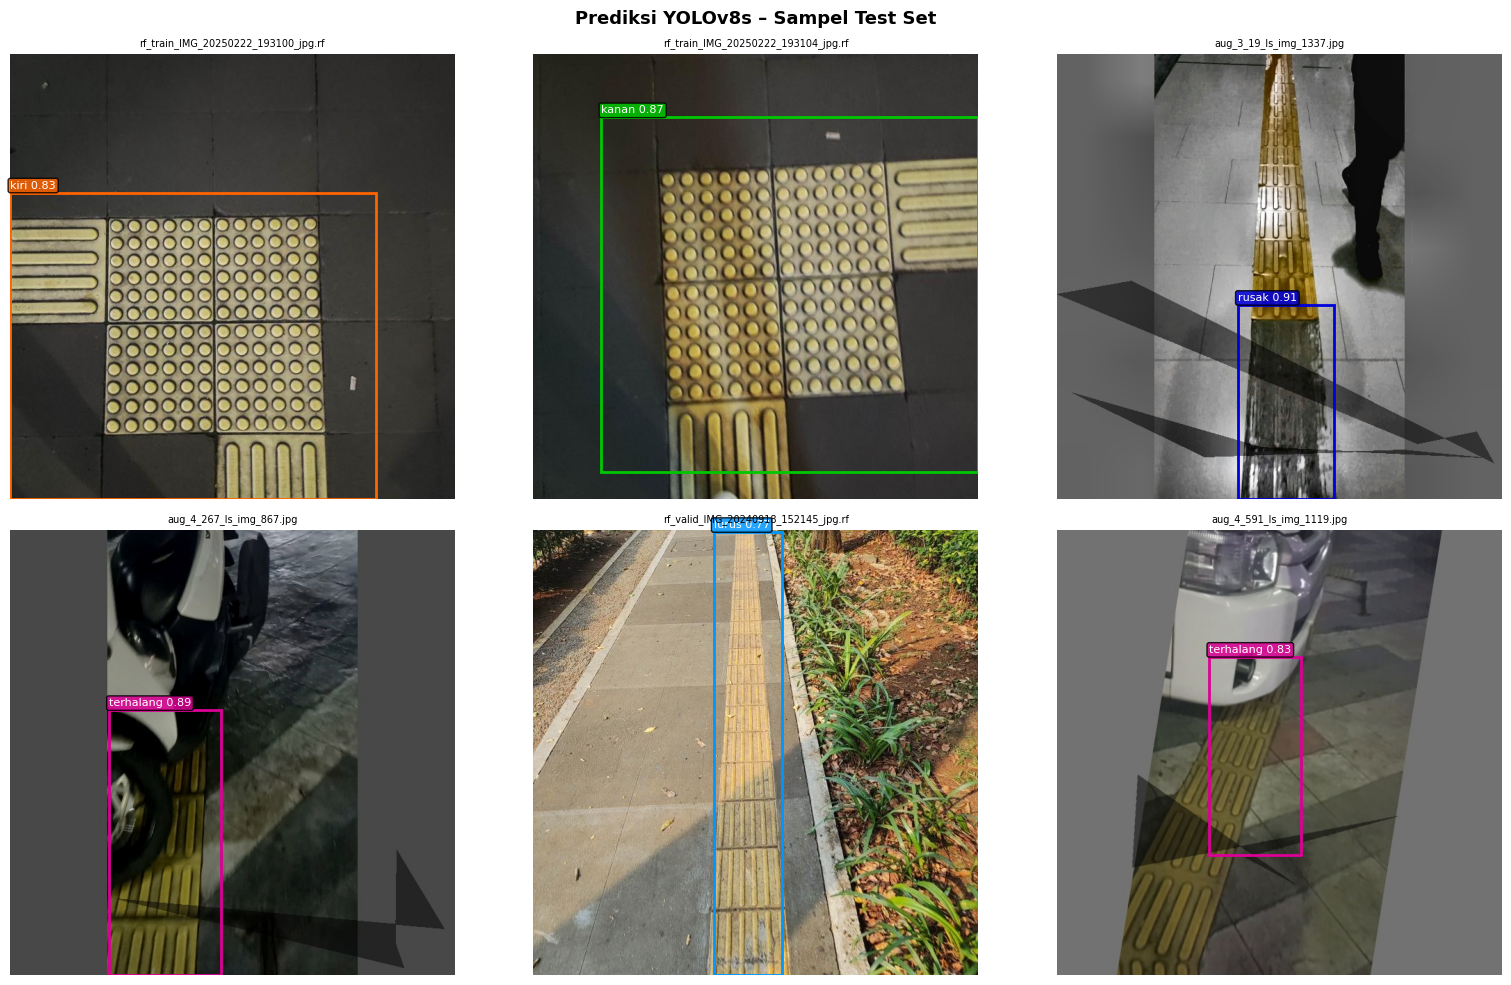

In [28]:
COLORS_BGR = {
    0: (0, 200, 0),
    1: (255, 100, 0),
    2: (0, 150, 255),
    3: (0, 0, 220),
    4: (220, 0, 150)
}

all_test_imgs = list(Path(TEST_IMG_DIR).iterdir())
sample_imgs   = random.sample(all_test_imgs, min(6, len(all_test_imgs)))

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, img_path in enumerate(sample_imgs):
    img_bgr = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    h, w    = img_rgb.shape[:2]

    preds = best_model.predict(str(img_path), conf=0.25, iou=0.5, verbose=False)
    ax    = axes[idx]
    ax.imshow(img_rgb)

    if preds and preds[0].boxes is not None:
        for box in preds[0].boxes:
            cls_id = int(box.cls.item())
            conf   = box.conf.item()
            x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
            color = [c/255 for c in COLORS_BGR.get(cls_id, (128, 128, 128))]
            rect  = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                       linewidth=2, edgecolor=color, facecolor='none')
            ax.add_patch(rect)
            ax.text(x1, y1-6, f'{CLASS_NAMES[cls_id]} {conf:.2f}',
                    color='white', fontsize=8,
                    bbox=dict(boxstyle='round,pad=0.2', fc=color, alpha=0.85))

    ax.set_title(img_path.name[:35], fontsize=7)
    ax.axis('off')

plt.suptitle('Prediksi YOLOv8s – Sampel Test Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'sample_predictions.png'), dpi=150)
plt.show()

In [29]:
print('              RINGKASAN HASIL AKHIR')
print(f'  Model          : YOLOv8s')
print(f'  Epochs dilatih : (sesuai early stopping dari {EPOCHS})')
print(f'  Image Size     : {IMG_SZ}×{IMG_SZ}')
print(f'  Batch Size     : {BATCH}')
print(f'  Kelas          : {CLASS_NAMES}')
print(f'  Total dataset  : {n} gambar (setelah aug)')
print()
print('  -- Metrik YOLOv8 (test set) --')
print(f'  mAP@50         : {test_results.box.map50:.4f}')
print(f'  mAP@50-95      : {test_results.box.map:.4f}')
print(f'  Precision      : {test_results.box.mp:.4f}')
print(f'  Recall         : {test_results.box.mr:.4f}')
if len(y_true_all) > 0:
    print()
    print('  -- Metrik sklearn (test set) --')
    print(f'  Accuracy       : {acc:.4f}  ({acc*100:.2f}%)')
    print(f'  Precision (W)  : {prec_weighted:.4f}')
    print(f'  Recall    (W)  : {rec_weighted:.4f}')
    print(f'  F1-Score (M)   : {f1:.4f}')

              RINGKASAN HASIL AKHIR
  Model          : YOLOv8s
  Epochs dilatih : (sesuai early stopping dari 100)
  Image Size     : 640×640
  Batch Size     : 16
  Kelas          : ['kanan', 'kiri', 'lurus', 'rusak', 'terhalang']
  Total dataset  : 1 gambar (setelah aug)

  -- Metrik YOLOv8 (test set) --
  mAP@50         : 0.8664
  mAP@50-95      : 0.5436
  Precision      : 0.8657
  Recall         : 0.8717

  -- Metrik sklearn (test set) --
  Accuracy       : 0.9173  (91.73%)
  Precision (W)  : 0.9196
  Recall    (W)  : 0.9173
  F1-Score (M)   : 0.9168


In [33]:
DRIVE_SAVE_DIR = '/content/drive/MyDrive/METOPEN/guiding-block-detection-yolov8'
os.makedirs(f'{DRIVE_SAVE_DIR}/results/sample_predictions', exist_ok=True)
os.makedirs(f'{DRIVE_SAVE_DIR}/models', exist_ok=True)
os.makedirs(f'{DRIVE_SAVE_DIR}/docs', exist_ok=True)

shutil.copy(BEST_MODEL_PATH, f'{DRIVE_SAVE_DIR}/models/best.pt')
print(f'best.pt tersimpan di Drive')

for fname in ['confusion_matrix.png', 'sample_predictions.png', 'training_curves.png', 'training_log.csv']:
    src = os.path.join(BASE_DIR, fname)
    if os.path.exists(src):
        shutil.copy(src, f'{DRIVE_SAVE_DIR}/results/{fname}')
        print(f'{fname} tersimpan di Drive')

runs_dir = os.path.join(PROJECT, EXP_NAME)
for fname in ['results.png', 'train_batch0.jpg', 'train_batch1.jpg', 'val_batch0_pred.jpg']:
    src = os.path.join(runs_dir, fname)
    if os.path.exists(src):
        shutil.copy(src, f'{DRIVE_SAVE_DIR}/results/{fname}')
        print(f'{fname} tersimpan di Drive')

for fname in ['confusion_matrix.png', 'confusion_matrix_normalized.png']:
    src = os.path.join(runs_dir, fname)
    if os.path.exists(src):
        shutil.copy(src, f'{DRIVE_SAVE_DIR}/results/yolo_{fname}')
        print(f'yolo_{fname} tersimpan di Drive')

print('\nSemua artifact berhasil disimpan ke Google Drive!')
print(f'Lokasi: {DRIVE_SAVE_DIR}')


best.pt tersimpan di Drive
confusion_matrix.png tersimpan di Drive
sample_predictions.png tersimpan di Drive
training_curves.png tersimpan di Drive
training_log.csv tersimpan di Drive
results.png tersimpan di Drive
train_batch0.jpg tersimpan di Drive
train_batch1.jpg tersimpan di Drive
val_batch0_pred.jpg tersimpan di Drive
yolo_confusion_matrix.png tersimpan di Drive
yolo_confusion_matrix_normalized.png tersimpan di Drive

Semua artifact berhasil disimpan ke Google Drive!
Lokasi: /content/drive/MyDrive/METOPEN/guiding-block-detection-yolov8


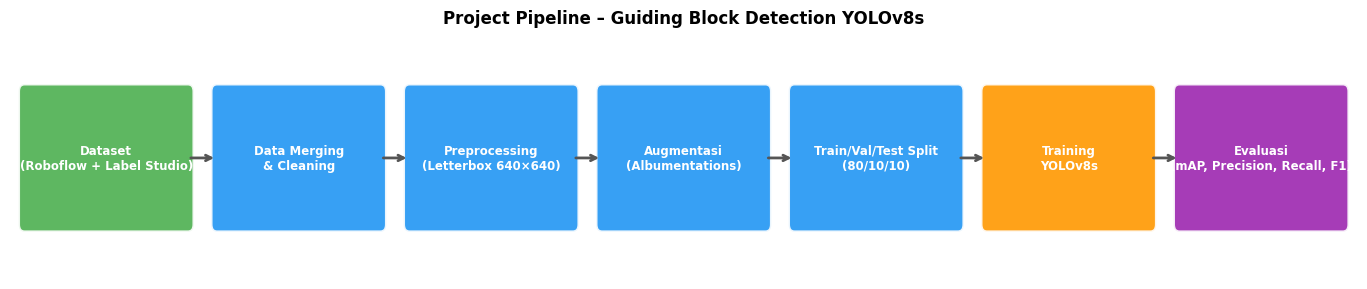

Pipeline diagram tersimpan: /content/drive/MyDrive/METOPEN/guiding-block-detection-yolov8/docs/project_pipeline.png


In [34]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch

steps = [
    ('Dataset\n(Roboflow + Label Studio)', '#4CAF50'),
    ('Data Merging\n& Cleaning', '#2196F3'),
    ('Preprocessing\n(Letterbox 640×640)', '#2196F3'),
    ('Augmentasi\n(Albumentations)', '#2196F3'),
    ('Train/Val/Test Split\n(80/10/10)', '#2196F3'),
    ('Training\nYOLOv8s', '#FF9800'),
    ('Evaluasi\n(mAP, Precision, Recall, F1)', '#9C27B0'),
]

fig, ax = plt.subplots(figsize=(14, 3))
ax.set_xlim(0, len(steps))
ax.set_ylim(0, 1)
ax.axis('off')

box_w, box_h = 0.85, 0.55
y_center = 0.5

for i, (label, color) in enumerate(steps):
    x = i + 0.5
    fancy = mpatches.FancyBboxPatch(
        (x - box_w/2, y_center - box_h/2), box_w, box_h,
        boxstyle='round,pad=0.03',
        facecolor=color, edgecolor='white', linewidth=2, alpha=0.9
    )
    ax.add_patch(fancy)
    ax.text(x, y_center, label, ha='center', va='center',
            fontsize=8.5, color='white', fontweight='bold', wrap=True)

    if i < len(steps) - 1:
        ax.annotate('', xy=(i + 1 + 0.5 - box_w/2, y_center),
                    xytext=(i + 0.5 + box_w/2, y_center),
                    arrowprops=dict(arrowstyle='->', color='#555', lw=2))

plt.title('Project Pipeline – Guiding Block Detection YOLOv8s',
          fontsize=12, fontweight='bold', pad=10)
plt.tight_layout()

pipeline_path = f'{DRIVE_SAVE_DIR}/docs/project_pipeline.png'
plt.savefig(pipeline_path, dpi=150, bbox_inches='tight', facecolor='#1e1e2e')
plt.show()
print(f'Pipeline diagram tersimpan: {pipeline_path}')
